In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=1000, n_features=5, noise=20, random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train_scaled, y_train)

y_pred = sgd.predict(X_test_scaled)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))
print("Coefficients:", sgd.coef_)
print("Intercept:", sgd.intercept_)

RMSE: 21.065557664893955
R2: 0.8941632027627083
Coefficients: [25.47765382 46.19587582 16.60276336 24.56920553 19.74556161]
Intercept: [-0.24705328]


In [6]:
for loss in ['squared_error', 'huber', 'epsilon_insensitive']:
    model = SGDRegressor(loss=loss, max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"{loss}: RMSE={np.sqrt(mean_squared_error(y_test, pred)):.4f}, R2={r2_score(y_test, pred):.4f}")

squared_error: RMSE=21.0656, R2=0.8942
huber: RMSE=42.7537, R2=0.5640
epsilon_insensitive: RMSE=21.2290, R2=0.8925


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [7]:
for penalty in [None, 'l2', 'l1', 'elasticnet']:
    if penalty is None:
        model = SGDRegressor(penalty=None, max_iter=1000, random_state=42)
    else:
        model = SGDRegressor(penalty=penalty, alpha=0.0001, max_iter=1000, random_state=42)
        if penalty == 'elasticnet':
            model.set_params(l1_ratio=0.5)
    
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"{penalty}: RMSE={np.sqrt(mean_squared_error(y_test, pred)):.4f}")

None: RMSE=21.0652
l2: RMSE=21.0656
l1: RMSE=21.0652
elasticnet: RMSE=21.0654


In [8]:
param_grid = {
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1'],
    'learning_rate': ['constant', 'optimal', 'invscaling'],
    'eta0': [0.001, 0.01]
}

grid = GridSearchCV(
    SGDRegressor(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
print("Best params:", grid.best_params_)
print("Best RMSE:", np.sqrt(-grid.best_score_))


Best params: {'alpha': 0.001, 'eta0': 0.001, 'learning_rate': 'constant', 'penalty': 'l2'}
Best RMSE: 20.727759600310762


In [9]:
sgd_online = SGDRegressor(warm_start=True, random_state=42)

n_batches = 10
batch_size = len(X_train_scaled) // n_batches

for i in range(n_batches):
    start = i * batch_size
    end = start + batch_size if i < n_batches - 1 else len(X_train_scaled)
    sgd_online.partial_fit(X_train_scaled[start:end], y_train[start:end])

y_pred_online = sgd_online.predict(X_test_scaled)
print("Online R2:", r2_score(y_test, y_pred_online))

Online R2: 0.8743084202508308


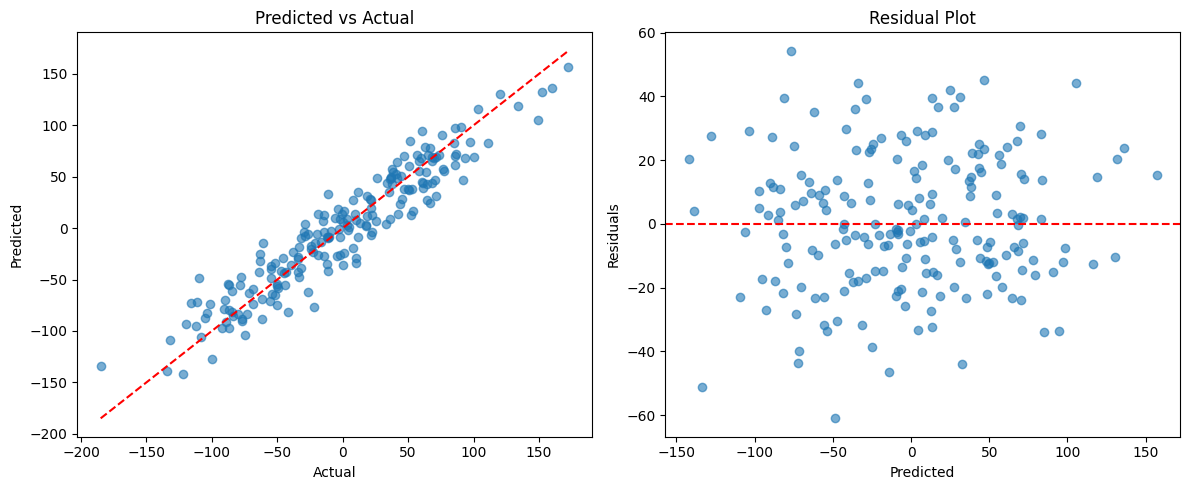

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()